# 02 - TF-IDF (Term Frequency - Inverse Document Frequency)

---

In the previous notebook, we learned how Bag of Words converts text into numerical vectors.

However, Bag of Words gives equal importance to every word, even very common words like **"the"**, **"is"**, and **"a"**.

In this notebook, we will learn how TF-IDF solves this problem by assigning higher importance to informative words and lower importance to common words.

## 📜 History

Bag of Words was one of the earliest techniques for representing text as numbers.

Although it worked well, researchers noticed a problem.

Consider these two sentences:

Sentence 1:
"The movie is good"

Sentence 2:
"The weather is good"

Words like:

- the
- is

appear almost everywhere.

These common words do not help distinguish one document from another.

Researchers wanted a way to reduce the importance of common words while increasing the importance of rare and meaningful words.

This led to the development of **TF-IDF (Term Frequency - Inverse Document Frequency)**.

## ❌ Why Bag of Words Was Not Enough

Bag of Words simply counts word occurrences.

Example:

Sentence:
"I love AI"

Vector:

love = 1

AI = 1

I = 1

Bag of Words treats every word equally.

But should these words have the same importance?

- the
- AI

Probably not.

Words like **"AI"**, **"Transformer"**, or **"NVIDIA"** carry much more information than words like **"the"** or **"is"**.

TF-IDF was introduced to solve this issue.

## 💡 Core Idea

TF-IDF measures how important a word is in a document.

It combines two concepts:

### Term Frequency (TF)

How often a word appears in a document.

### Inverse Document Frequency (IDF)

How rare the word is across all documents.

Important words receive higher scores.

Very common words receive lower scores.

## 🧠 Step 1: Term Frequency (TF)

Term Frequency measures how often a word appears in a document.

Formula:

TF = (Number of times the word appears) / 
      Total number of words

Example:

Document:

AI is amazing AI

Word = AI

TF = 2 / 4 = 0.5

# Hands-on with TF

In [1]:
sentence = "AI is amazing AI"

words = sentence.split()

target = "AI"

tf = words.count(target) / len(words)

print("Words:", words)
print("Term Frequency:", tf)

Words: ['AI', 'is', 'amazing', 'AI']
Term Frequency: 0.5


## 🧠 Step 2: Inverse Document Frequency (IDF)

Some words appear in almost every document.

Example:

the

is

a

These words are not very useful.

IDF reduces their importance.

Formula:

IDF = log(Total Documents / Number of Documents Containing the Word)

Rare words get larger IDF values.

Common words get smaller IDF values.

# Hands-on with IDF

In [2]:
import math

documents = [
    "AI is amazing",
    "AI is powerful",
    "Machine learning is interesting"
]

target = "AI"

docs_with_word = sum(target in doc.split() for doc in documents)

idf = math.log(len(documents) / docs_with_word)

print("Documents:", len(documents))
print("Documents containing AI:", docs_with_word)
print("IDF:", round(idf,3))

Documents: 3
Documents containing AI: 2
IDF: 0.405


## 🧠 Final TF-IDF Score

The final score is:

TF × IDF

High TF

AND

High IDF

↓

Important word

Example:

Word: Transformer

Appears many times in one document.

Appears rarely in all documents.

↓

High TF-IDF score.

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

sentences = [
    "I love AI",
    "AI is amazing",
    "Machine learning is interesting",
    "I hate bugs"
]

vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(sentences)

tfidf = pd.DataFrame(
    X.toarray(),
    columns=vectorizer.get_feature_names_out()
)

tfidf.round(3)

,ai,amazing,bugs,hate,interesting,is,learning,love,machine
0,0.619,0.000,0.000,0.000,0.000,0.000,0.000,0.785,0.000
1,0.526,0.668,0.000,0.000,0.000,0.526,0.000,0.000,0.000
2,0.000,0.000,0.000,0.000,0.525,0.414,0.525,0.000,0.525
3,0.000,0.000,0.707,0.707,0.000,0.000,0.000,0.000,0.000


## 📖 Understanding the TF-IDF Matrix

Each row represents one document.

Each column represents one word.

Each value represents the importance of that word in that document.

Unlike Bag of Words,

the values are no longer simple counts.

They are weighted scores.

# Train an ML Model

In [4]:
from sklearn.linear_model import LogisticRegression

labels = [1,1,1,0]

model = LogisticRegression()

model.fit(X, labels)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [5]:
#Prediction
test = ["I love machine learning"]

prediction = model.predict(
    vectorizer.transform(test)
)

print(prediction)

[1]


# Compare BOW vs TF-IDF

In [6]:
from sklearn.feature_extraction.text import CountVectorizer

bow = CountVectorizer()

bow_matrix = bow.fit_transform(sentences)

print("Bag of Words")

print(pd.DataFrame(
    bow_matrix.toarray(),
    columns=bow.get_feature_names_out()
))

print()

print("TF-IDF")

print(tfidf.round(2))

Bag of Words
   ai  amazing  bugs  hate  interesting  is  learning  love  machine
0   1        0     0     0            0   0         0     1        0
1   1        1     0     0            0   1         0     0        0
2   0        0     0     0            1   1         1     0        1
3   0        0     1     1            0   0         0     0        0

TF-IDF
     ai  amazing  bugs  hate  interesting    is  learning  love  machine
0  0.62     0.00  0.00  0.00         0.00  0.00      0.00  0.79     0.00
1  0.53     0.67  0.00  0.00         0.00  0.53      0.00  0.00     0.00
2  0.00     0.00  0.00  0.00         0.53  0.41      0.53  0.00     0.53
3  0.00     0.00  0.71  0.71         0.00  0.00      0.00  0.00     0.00


# Visualization

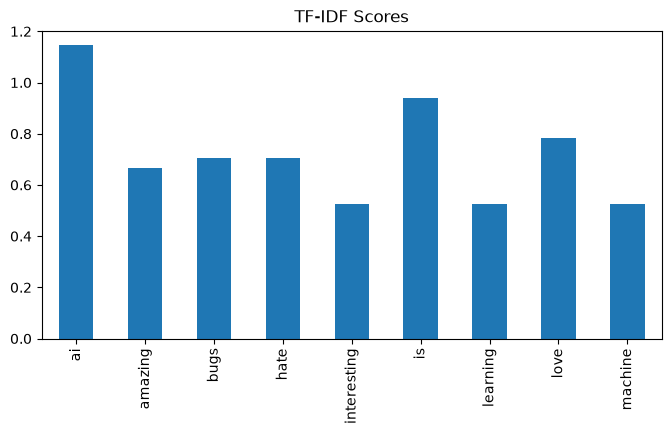

In [7]:
import matplotlib.pyplot as plt

scores = tfidf.sum()

plt.figure(figsize=(8,4))

scores.plot(kind="bar")

plt.title("TF-IDF Scores")

plt.show()

## ✅ Advantages

- Better than Bag of Words
- Reduces importance of common words
- Highlights important words
- Easy to implement
- Works well for document classification